# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector
material**. Each section runs the same pipeline (load Mathematica response
matrix → forward model `exposure · M @ eta` → recover the monotone non-negative
flux `x(v_min)`) for a different `material`:

- **TES (Al)** — Mermin dielectric, threshold 0.1 eV, fine binning `R10`.
- **MKID (TiN)** — analytic Lindhard dielectric, threshold 0.2 eV, fine binning `R9`.

The only thing that changes between detectors is `material` (`'Al'` / `'TiN'`):
the package maps it to the right Mathematica output tree (`output/TES` /
`output/MKID`) and exposure automatically.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, background=background))
        flux = a.optimize(solver=solver)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {eta}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

Aluminium detector, Mermin dielectric. Available matrices: heavy (`q0`) and
light (`q2`) mediators, 5-bin (`R5`) and 10-bin (`R10`) binnings.

## Heavy mediator (q0), 5 energy bins, Halo, signal only

Polishing not needed - no active set detected at optimal point
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 143 v_min bins, peak flux 7.94e-31
Polishing not needed - no active set detected at optimal point


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 68 v_min bins, peak flux 8.26e-32
Polishing not needed - no active set detected at optimal point
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 71 v_min bins, peak flux 8.28e-33


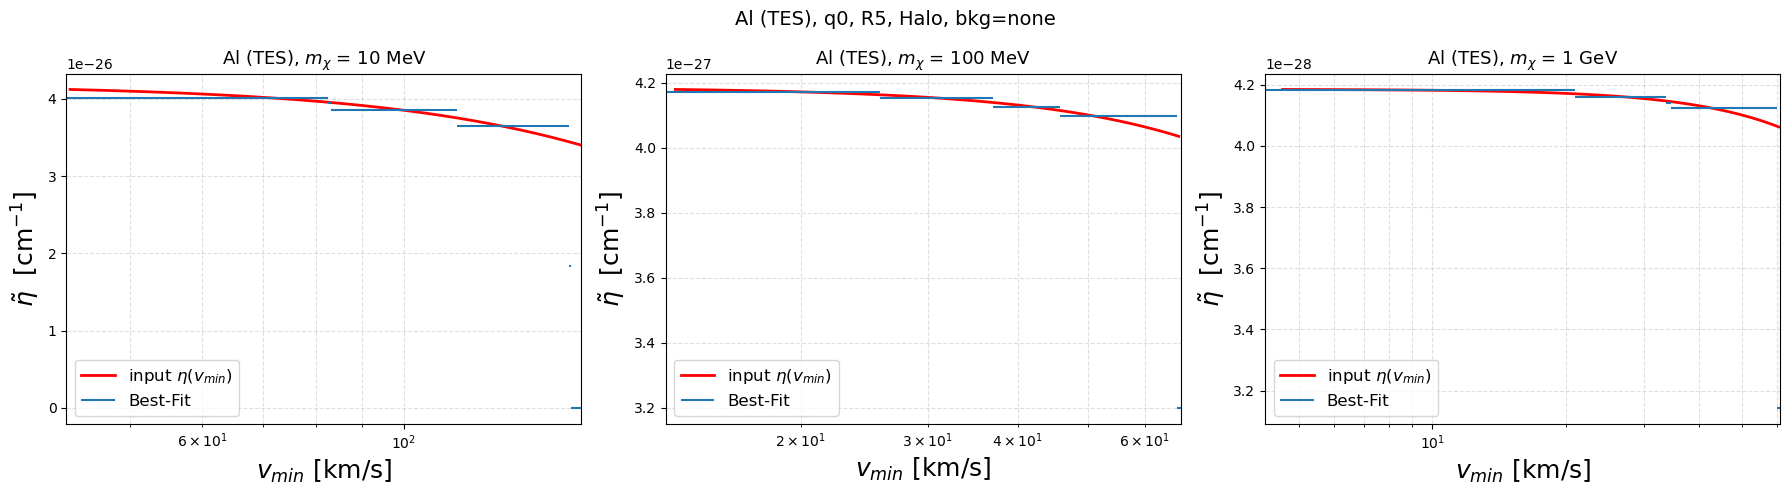

In [2]:
run_masses('Al', q='0', nbins=5)

## Light mediator (q2), 5 energy bins

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 265 v_min bins, peak flux 7.96e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 280 v_min bins, peak flux 8.32e-32


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 289 v_min bins, peak flux 8.38e-33


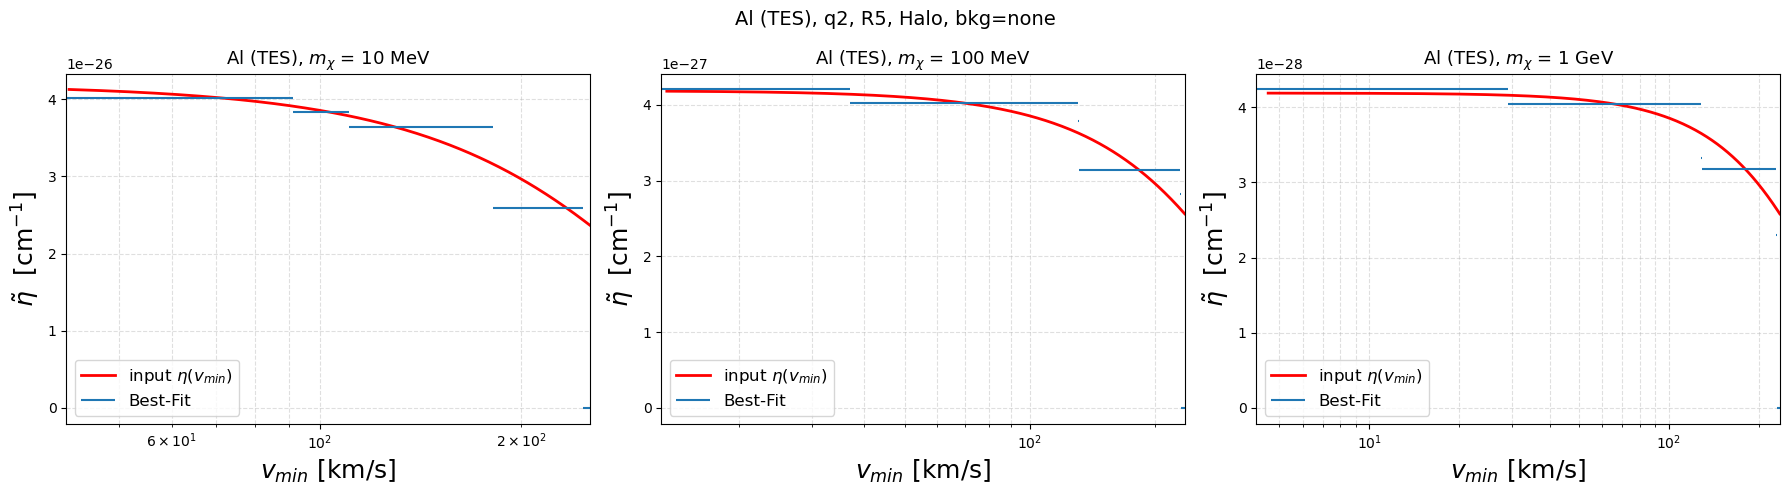

In [3]:
run_masses('Al', q='2', nbins=5)

## Finer energy binning (R10)

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 147 v_min bins, peak flux 8.01e-31
Polishing not needed - no active set detected at optimal point
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 71 v_min bins, peak flux 8.27e-32
Polishing not needed - no active set detected at optimal point


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Halo/flux.pdf
Al q0 M3 R10: 10 E-bins x 74 v_min bins, peak flux 8.29e-33


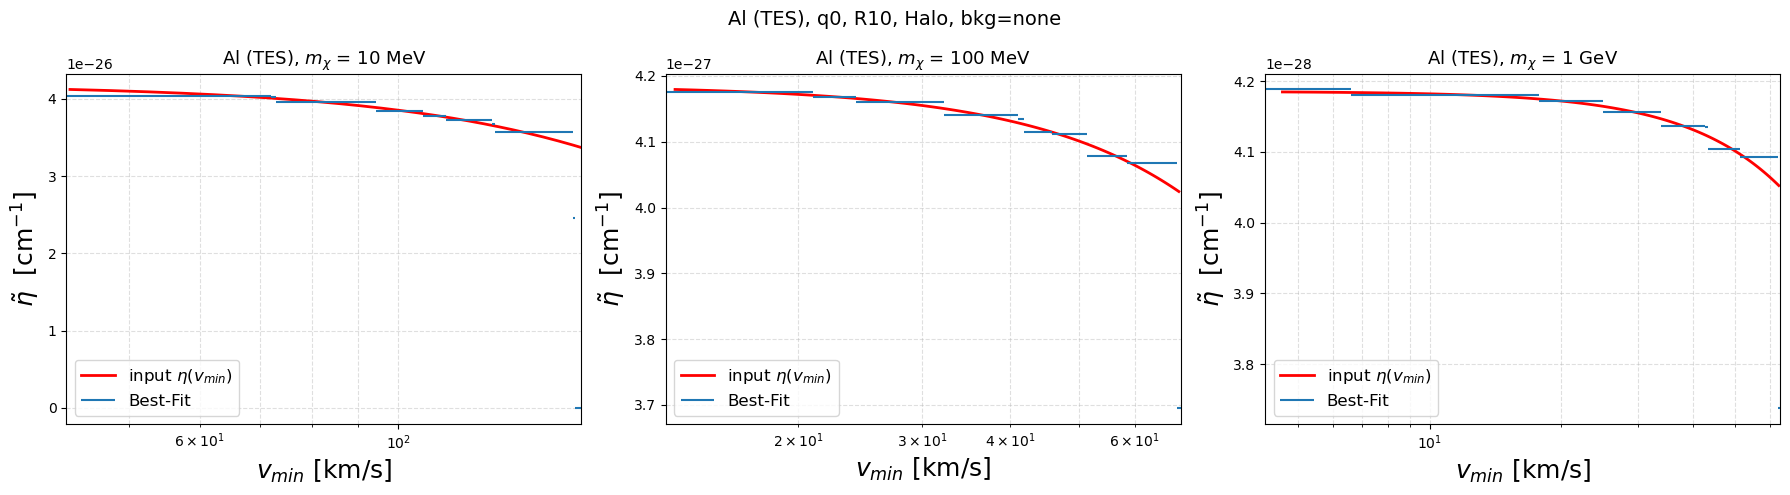

In [4]:
run_masses('Al', q='0', nbins=10)

Polishing not needed - no active set detected at optimal point


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 276 v_min bins, peak flux 8.08e-31


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 292 v_min bins, peak flux 8.26e-32


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Halo/flux.pdf
Al q2 M3 R10: 10 E-bins x 301 v_min bins, peak flux 8.28e-33


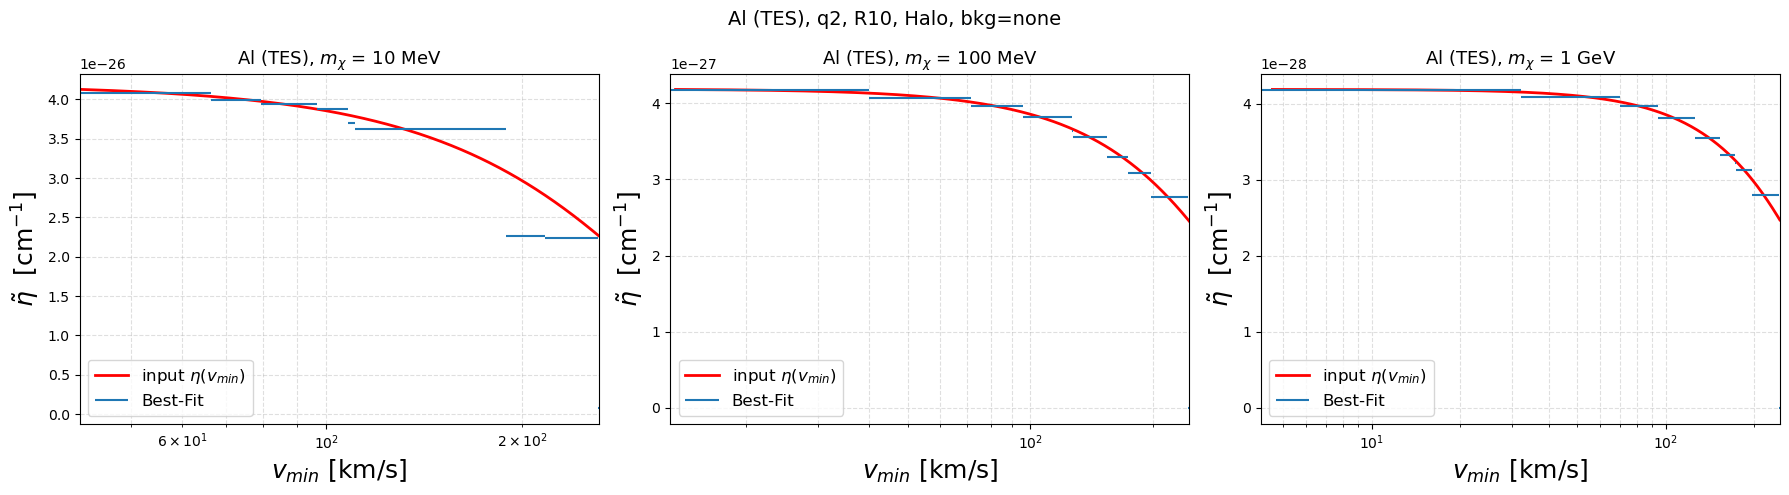

In [5]:
run_masses('Al', q='2', nbins=10)

## With a background scenario

Polishing not needed - no active set detected at optimal point
signal     : [0.16550434 0.33066231 0.48524687 0.64601833 0.78726601]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]


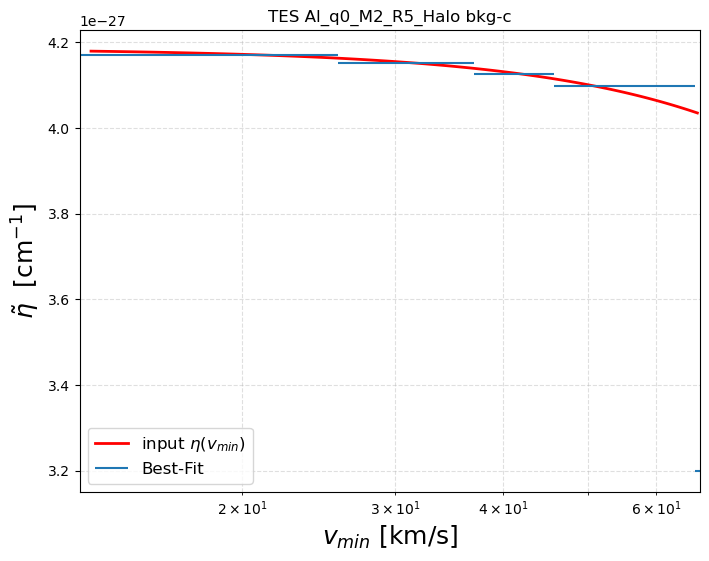

In [6]:
a = DarkMatterQuantumAnalysis(
    RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', background='c'))
a.optimize(solver='osqp')
print('signal     :', a.signal)
print('background :', a.background)
a.plot(save=False); plt.show()

# MKID (TiN)

Titanium-nitride detector, analytic Lindhard dielectric. The detection
**threshold is 0.2 eV**, so the energy bins start at 0.2 eV and the fine
binning is **`R9`** (0.2–1.1 eV in 0.1 eV steps), not `R10`.

Currently generated: heavy mediator (`q0`), masses M1–M3, `R5` and `R9`. The
light mediator (`q2`) requires generating the MKID `q2` matrices first
(`08_response_functions.wl … q2` → `10_response_matrix.wl` → `12_eta.wl`).

## Heavy mediator (q0), 5 energy bins, Halo, signal only

Polishing not needed - no active set detected at optimal point


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 120 v_min bins, peak flux 7.95e-31
Polishing not needed - no active set detected at optimal point


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 118 v_min bins, peak flux 8.24e-32
Polishing not needed - no active set detected at optimal point
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 128 v_min bins, peak flux 8.25e-33


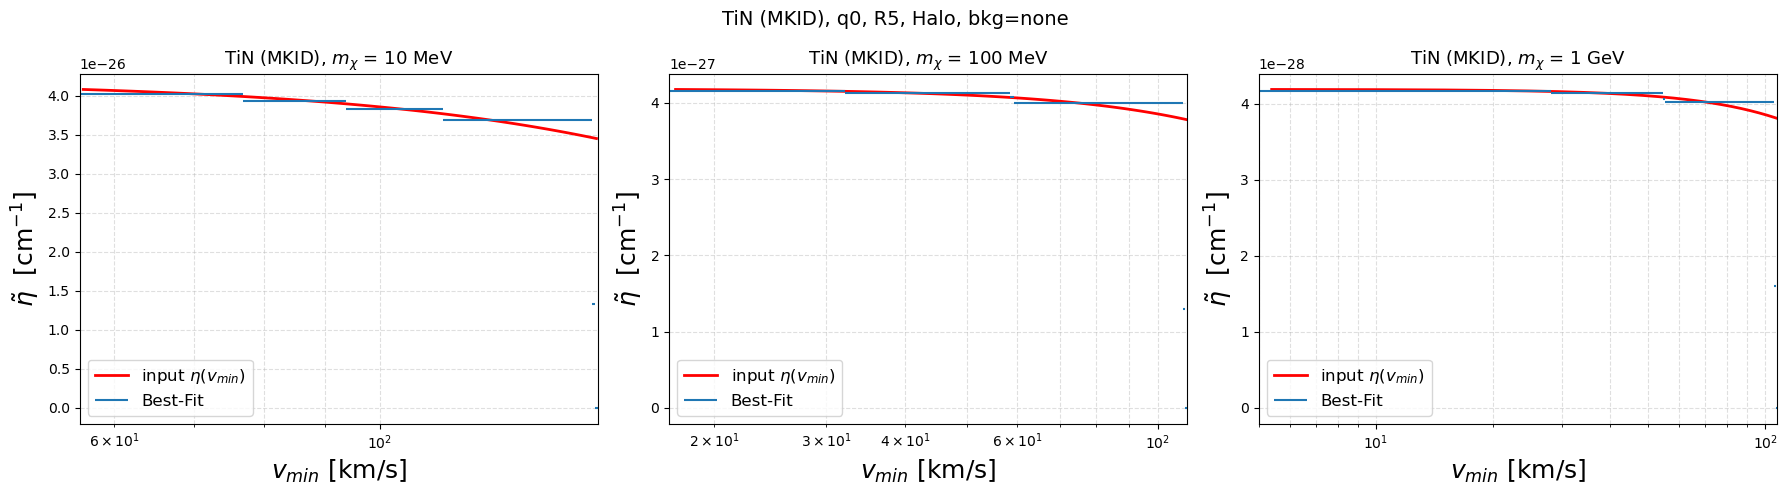

In [7]:
run_masses('TiN', q='0', nbins=5)

## Finer energy binning (R9)

Polishing not needed - no active set detected at optimal point
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 125 v_min bins, peak flux 7.95e-31


saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 124 v_min bins, peak flux 8.24e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Halo/flux.pdf
TiN q0 M3 R9: 9 E-bins x 134 v_min bins, peak flux 8.25e-33


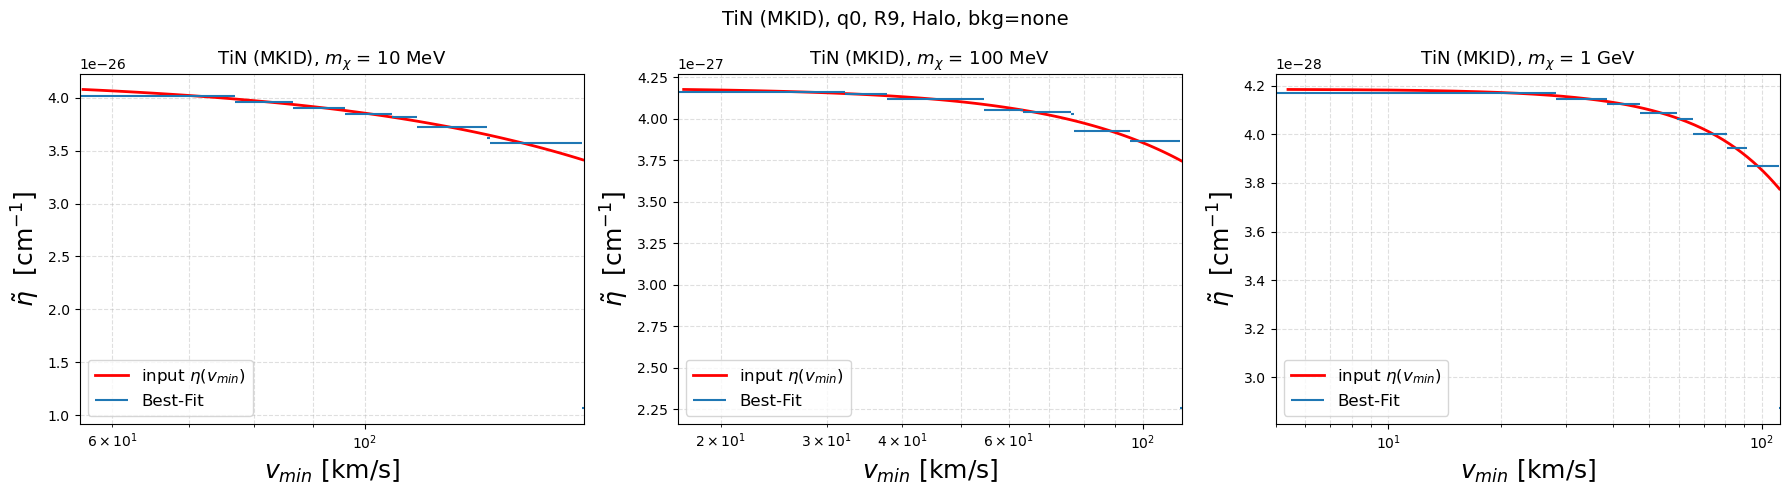

In [8]:
run_masses('TiN', q='0', nbins=9)